# **Exploring San Francisco MUNI GTFS Data**

**Author:** Ayemhenre Isikhuemhen  
**Dataset:** SF MUNI General Transit Feed Specification (GTFS) Current Feed  
**Source:** San Francisco Municipal Transportation Agency (SFMTA)  

**File Description:** This notebook explores the GTFS data files for San Francisco's MUNI transit system. GTFS (General Transit Feed Specification) is a standardized format for public transportation schedules and geographic information. The objective is to examine each data file, understand its structure, and build visualizations; including route maps, fare analysis, schedule patterns, and network graphs to gain insight into how San Francisco moves its passengers.

---

## Setup
**Setup for the GTFS notebook: Import Libraries & File Paths**

In [78]:
# Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries Imported")

Libraries Imported


In [79]:
# File Paths

# Update BASE_DIR if running on a different machine.
BASE_DIR = r"C:\Users\Owner\Documents\GitHub\GTFS-Exploration\GTFS Data Exploration\Data Files\San Francisco (muni_gtfs-current)"

import os
paths = {
    "agency"         : os.path.join(BASE_DIR, "agency.txt"),
    "calendar"       : os.path.join(BASE_DIR, "calendar.txt"),
    "calendar_dates" : os.path.join(BASE_DIR, "calendar_dates.txt"),
    "directions"     : os.path.join(BASE_DIR, "directions.txt"),
    "fare_attributes": os.path.join(BASE_DIR, "fare_attributes.txt"),
    "fare_rules"     : os.path.join(BASE_DIR, "fare_rules.txt"),
    "routes"         : os.path.join(BASE_DIR, "routes.txt"),
    "shapes"         : os.path.join(BASE_DIR, "shapes.txt"),
    "stop_times"     : os.path.join(BASE_DIR, "stop_times.txt"),
    "stops"          : os.path.join(BASE_DIR, "stops.txt"),
    "timepoints"     : os.path.join(BASE_DIR, "timepoints.txt"),
    "trips"          : os.path.join(BASE_DIR, "trips.txt"),
}

# Load all files
dfs = {name: pd.read_csv(path) for name, path in paths.items()}

print("Files Loaded:")
for name, df in dfs.items():
    print(f"  {name:<20} :  {df.shape[0]:>7,} rows  ×  {df.shape[1]:>3} cols")

Files Loaded:
  agency               :        1 rows  ×    8 cols
  calendar             :        3 rows  ×   10 cols
  calendar_dates       :       38 rows  ×    3 cols
  directions           :      136 rows  ×    3 cols
  fare_attributes      :        2 rows  ×    7 cols
  fare_rules           :       68 rows  ×    2 cols
  routes               :       68 rows  ×   10 cols
  shapes               :   45,050 rows  ×    5 cols
  stop_times           :  1,296,224 rows  ×    8 cols
  stops                :    3,243 rows  ×    8 cols
  timepoints           :  244,847 rows  ×    2 cols
  trips                :   34,632 rows  ×    9 cols


---

## File 1: Agency

**File:** `agency.txt`  
**Description:** Identifies the transit agency or agencies providing the data. For SF MUNI, this will be a single-row file describing the San Francisco Municipal Transportation Agency (SFMTA). It contains the agency name, URL, timezone, and contact information. This file is primarily metadata.

In [80]:
# DF Setup
agency_df = dfs["agency"]

In [81]:
# Shape and Columns of Agency
print(f"Shape        : {agency_df.shape}")
print(f"Columns      : {list(agency_df.columns)}")

Shape        : (1, 8)
Columns      : ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone', 'agency_fare_url', 'agency_email']


In [82]:
# Display the Agency Data Frame
display(agency_df)

,agency_id,agency_name,agency_url,agency_timezone,agency_lang,agency_phone,agency_fare_url,agency_email
0,SFMTA,San Francisco Municipal Transportation Agency,http://www.sfmta.com,America/Los_Angeles,en,311,https://SFMTA.com/Fares,munifeedback@sfmta.com


---

## File 2: Routes

**File:** `routes.txt`  
**Description:** Defines each transit route — bus lines, cable cars, metro lines, and streetcars. Each row is a unique route with a short name (e.g., "1", "N", "F"), a longer description, a route type code (bus = 3, tram = 0, cable car = 5, etc.), and optional color-coding used in maps and apps.

**Route Type Codes (GTFS Standard):**
- `0` = Tram / Streetcar
- `1` = Subway / Metro
- `3` = Bus
- `5` = Cable Car

In [83]:
# DF Setup
routes_df = dfs["routes"]

In [84]:
# Shapes and Columns for Routes
print(f"Total Routes  : {len(routes_df)}")
print(f"Columns       : {list(routes_df.columns)}")

Total Routes  : 68
Columns       : ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_url', 'route_desc', 'route_type', 'route_color', 'route_text_color', 'route_sort_order']


In [85]:
# Route Distribution
type_labels = {0: "Tram/Streetcar", 1: "Subway/Metro", 3: "Bus", 5: "Cable Car"}
type_counts = routes_df["route_type"].value_counts().rename(index=type_labels)
print(type_counts.to_string())

route_type
Bus               57
Tram/Streetcar     8
Cable Car          3


In [86]:
# Display Routes
display(routes_df[["route_id", "route_short_name", "route_long_name", "route_type"]]) # Add .Head(N) to show varying amounts

,route_id,route_short_name,route_long_name,route_type
0,1,1,CALIFORNIA,3
1,12,12,FOLSOM-PACIFIC,3
2,14,14,MISSION,3
3,14R,14R,MISSION RAPID,3
4,15,15,BAYVIEW HUNTERS POINT EXPRESS,3
...,...,...,...,...
63,NOWL,NOWL,OWL JUDAH,3
64,PH,PH,POWELL-HYDE CABLE CAR,5
65,PM,PM,POWELL-MASON CABLE CAR,5
66,T,T,THIRD,0


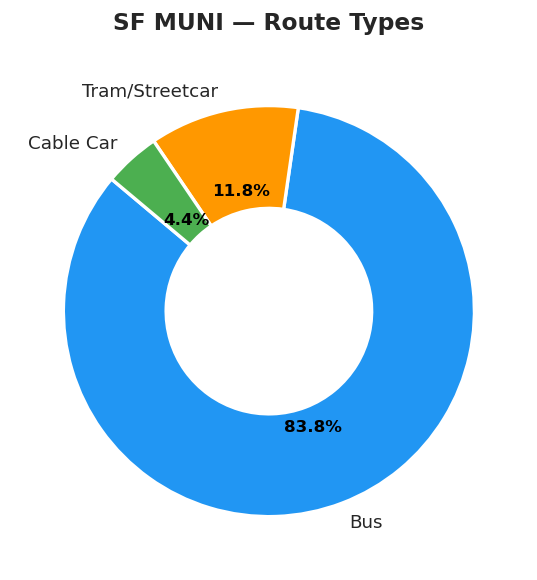

In [87]:
# Visualization: Donut Charte - Route Type Distribution

# Data Setup
type_labels = {0: "Tram/Streetcar", 1: "Subway/Metro", 3: "Bus", 5: "Cable Car"}
type_counts = routes_df["route_type"].map(type_labels).value_counts()

# Generate Chart
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors[:len(type_counts)],
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops={'fontsize': 11}
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_color("black")
    at.set_fontweight("bold")
ax.set_title("SF MUNI — Route Types", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

---

## File 3: Stops
**File:** `stops.txt`  
**Description:** Contains every physical bus stop, metro station, or cable car stop in the MUNI system. Each row has a unique stop ID, a name, and geographic coordinates (latitude/longitude). Some stops also include wheelchair accessibility information. This file is foundational — it anchors the entire transit network in physical space.

In [88]:
# DF Setup
stops_df = dfs["stops"]

In [89]:
# Shape and Columns of Stops
print(f"Total Stops   : {len(stops_df):,}")
print(f"Columns       : {list(stops_df.columns)}")

Total Stops   : 3,243
Columns       : ['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url']


In [90]:
# Range of Logitudes and Latitudes of Stops
print(f"Lat range     : {stops_df['stop_lat'].min():.4f} → {stops_df['stop_lat'].max():.4f}")
print(f"Lon range     : {stops_df['stop_lon'].min():.4f} → {stops_df['stop_lon'].max():.4f}")

Lat range     : 37.7059 → 37.8298
Lon range     : -122.5108 → -122.3670


In [91]:
# Display Stops
display(stops_df.head(5))

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url
0,390,10390,19th Avenue & Holloway St,,37.721190,-122.475153,,https://SFMTA.com/10390
1,913,10913,Dublin St & La Grande Ave,,37.719192,-122.425802,,https://SFMTA.com/10913
2,3016,13016,3rd St & 4th St,,37.772618,-122.389786,,https://SFMTA.com/13016
3,3018,13018,Bacon St & San Bruno Ave,,37.727859,-122.402994,,https://SFMTA.com/13018
4,3019,13019,Bacon St & San Bruno Ave,,37.727645,-122.403269,,https://SFMTA.com/13019


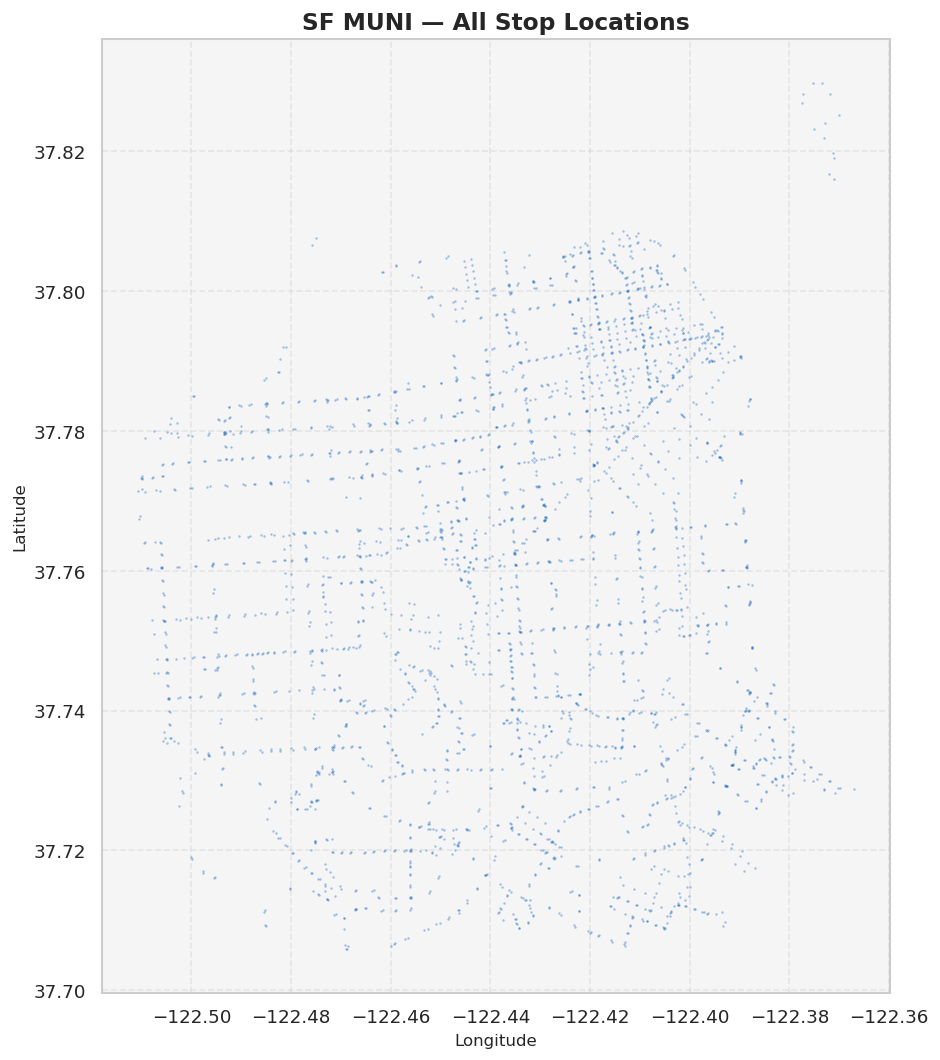

In [92]:
# Visualization: Stop Scatter Map

fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(
    stops_df["stop_lon"],
    stops_df["stop_lat"],
    s=2, alpha=0.4, color="#1565C0", linewidths=0
)
ax.set_title("SF MUNI — All Stop Locations", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)
ax.set_facecolor("#F5F5F5")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

---

## File 4: Trips

**File:** `trips.txt`  
**Description:** A trip is a single journey along a route e.g., one bus completing its full run from start to end. Each row links a trip to a route, a service calendar (weekday/weekend), a headsign (destination sign shown on the vehicle), a shape (geographic path), and a direction (inbound/outbound). This file bridges routes with the actual scheduled runs.

In [93]:
# DF Setup
trips_df = dfs["trips"]

In [94]:
# Notable Stats (Total Trips, Unique Routes)
print(f"Total Trips   : {len(trips_df):,}")
print(f"Unique Routes : {trips_df['route_id'].nunique()}")

Total Trips   : 34,632
Unique Routes : 68


In [95]:
# Display Trips
display(trips_df.head(5))

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed
0,38R,M11,11917123_M11,Transit Center,1,3832_M11,13852,1,1
1,38R,M21,11917123_M21,Transit Center,1,3832_M21,13852,1,1
2,38R,M11,11917124_M11,Transit Center,1,3841_M11,13852,1,1
3,38R,M21,11917124_M21,Transit Center,1,3841_M21,13852,1,1
4,38R,M11,11917125_M11,Transit Center,1,3842_M11,13852,1,1


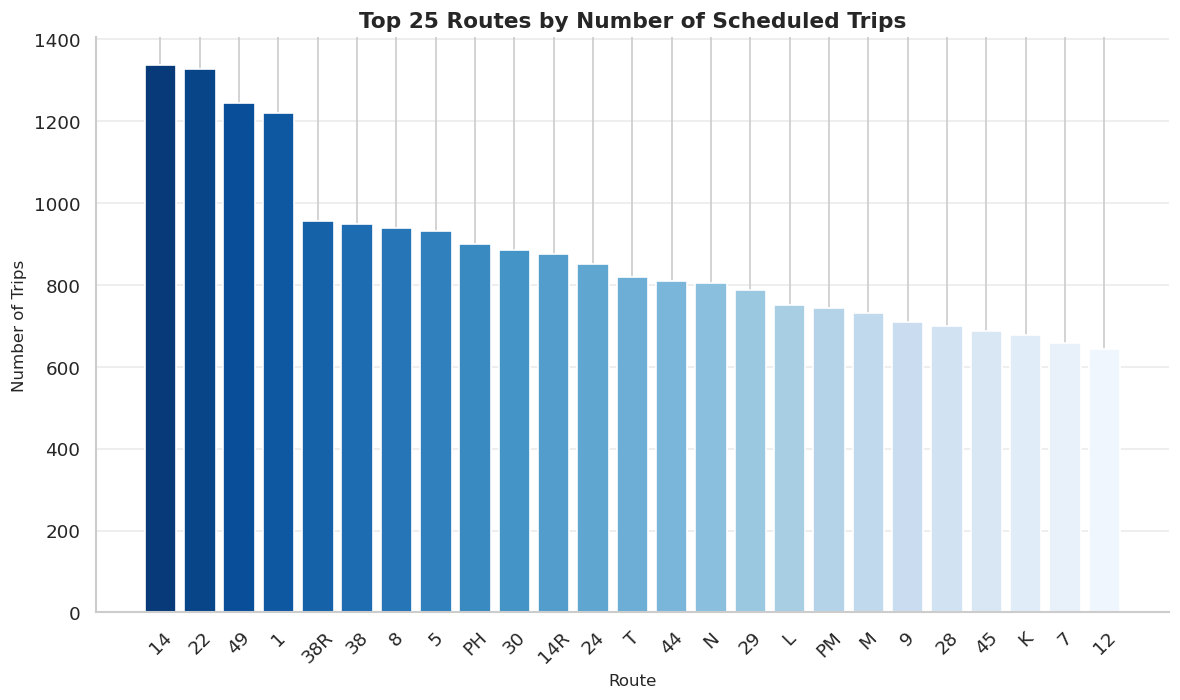

In [96]:
# Visualization: Trips per Route (Top 25)

trips_per_route = trips_df.groupby("route_id").size().sort_values(ascending=False).head(25) # Top by N amount in Head

# Attempt to label with short route names
if "route_short_name" in routes_df.columns:
    name_map = routes_df.set_index("route_id")["route_short_name"].to_dict()
    trips_per_route.index = [name_map.get(r, r) for r in trips_per_route.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = sns.color_palette("Blues_r", len(trips_per_route))
bars = ax.bar(trips_per_route.index, trips_per_route.values, color=colors_bar, edgecolor="white")
ax.set_title("Top 25 Routes by Number of Scheduled Trips", fontsize=13, fontweight="bold")
ax.set_xlabel("Route", fontsize=10)
ax.set_ylabel("Number of Trips", fontsize=10)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

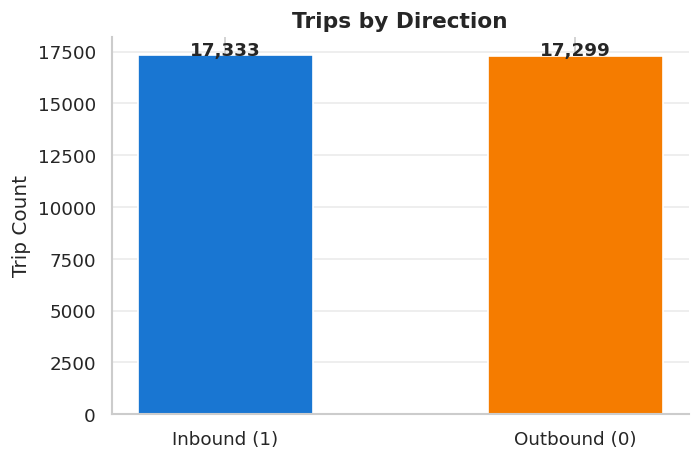

In [97]:
# Visualization: Trip Direction Split

if "direction_id" in trips_df.columns:
    dir_counts = trips_df["direction_id"].map({0: "Outbound (0)", 1: "Inbound (1)"}).value_counts()
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(dir_counts.index, dir_counts.values, color=["#1976D2", "#F57C00"], width=0.5, edgecolor="white")
    for i, v in enumerate(dir_counts.values):
        ax.text(i, v + 20, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
    ax.set_title("Trips by Direction", fontsize=13, fontweight="bold")
    ax.set_ylabel("Trip Count")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()

---

## File 5: Stop Times

**File:** `stop_times.txt`  
**Description:** The most granular file in GTFS — every scheduled arrival and departure time for every stop on every trip. This is typically the largest file. Each row says: "on trip X, vehicle arrives at stop Y at time Z." This file enables schedule analysis, frequency calculations, and headway computation. This file can be very large (100k–1M+ rows).

In [98]:
# DF Setup
st_df = dfs["stop_times"]

In [99]:
print("Stop Times Summary")
print(f"Total Records  : {len(st_df):,}")
print(f"Unique Trips   : {st_df['trip_id'].nunique():,}")
print(f"Unique Stops   : {st_df['stop_id'].nunique():,}")
print(f"Columns        : {list(st_df.columns)}")

Stop Times Summary
Total Records  : 1,296,224
Unique Trips   : 34,632
Unique Stops   : 3,243
Columns        : ['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence', 'stop_headsign', 'shape_dist_traveled', 'timepoint']


In [100]:
# DF Head
display(st_df.head(5))

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,shape_dist_traveled,timepoint
0,11898277_M11,04:32:00,04:32:00,3892,1,NaN,0.000000,1
1,11898277_M11,04:32:41,04:32:41,3875,2,NaN,0.172503,0
2,11898277_M11,04:33:28,04:33:28,3896,3,NaN,0.370289,0
3,11898277_M11,04:34:12,04:34:12,3852,4,NaN,0.553436,0
4,11898277_M11,04:34:45,04:34:45,3845,5,NaN,0.689304,0


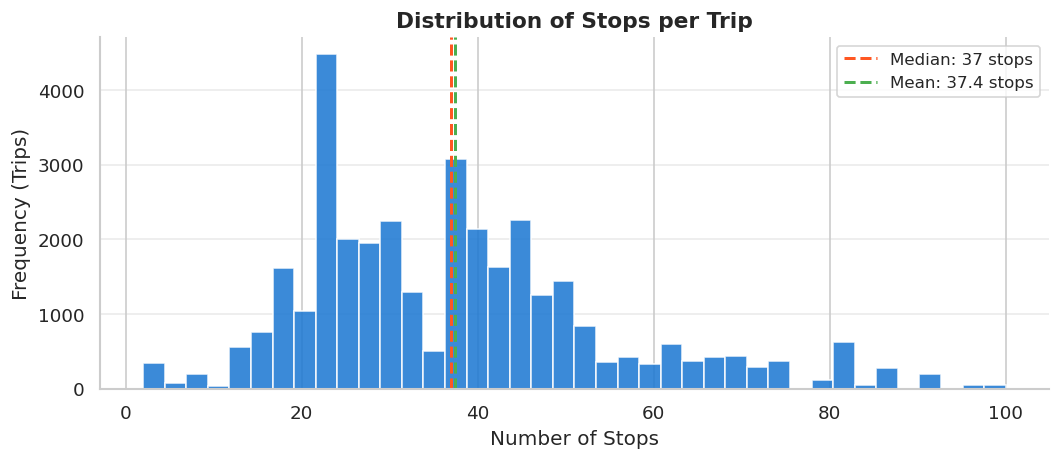

In [101]:
# Visualization: Stops per Trip Distribution

stops_per_trip = st_df.groupby("trip_id")["stop_id"].count()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(stops_per_trip, bins=40, color="#1976D2", edgecolor="white", alpha=0.85)
ax.axvline(stops_per_trip.median(), color="#FF5722", linestyle="--", linewidth=1.8,
           label=f"Median: {stops_per_trip.median():.0f} stops")
ax.axvline(stops_per_trip.mean(), color="#4CAF50", linestyle="--", linewidth=1.8,
           label=f"Mean: {stops_per_trip.mean():.1f} stops")
ax.set_title("Distribution of Stops per Trip", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Stops")
ax.set_ylabel("Frequency (Trips)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

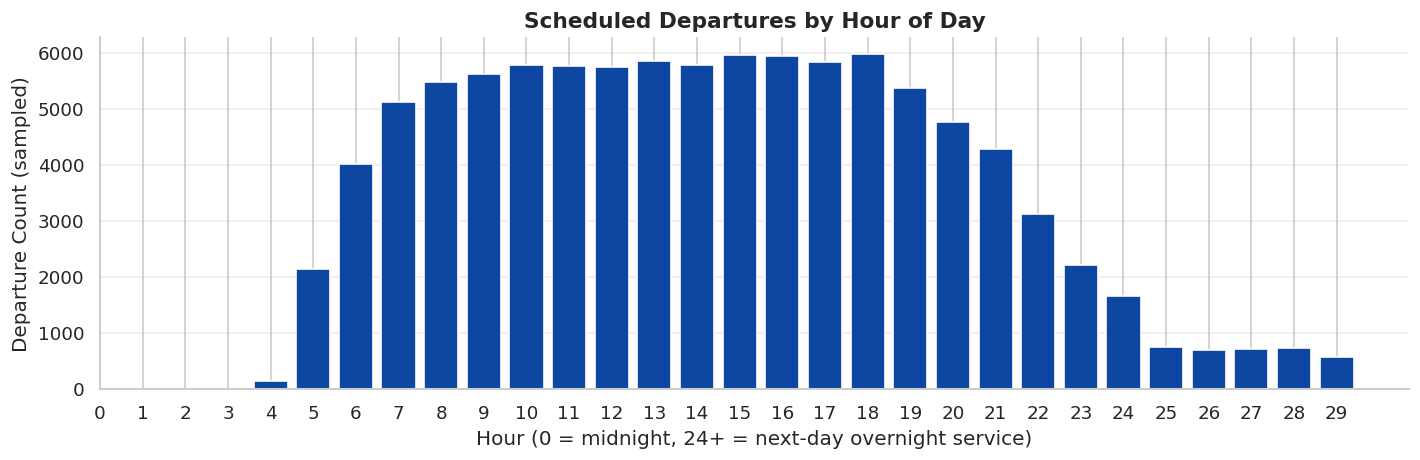

In [102]:
# Visualization: Service Activity by Hour of Day

def parse_gtfs_hour(time_str):
    try:
        return int(str(time_str).split(":")[0])
    except:
        return np.nan

# Sample for speed (use full dataset)
sample_st = st_df.sample(min(100_000, len(st_df)), random_state=42)
sample_st["dep_hour"] = sample_st["departure_time"].apply(parse_gtfs_hour)

# Cap at hour 29 (GTFS max reasonable)
hour_counts = sample_st[sample_st["dep_hour"].between(0, 29)]["dep_hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_counts.index, hour_counts.values, color="#0D47A1", edgecolor="white", width=0.8)
ax.set_title("Scheduled Departures by Hour of Day", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour (0 = midnight, 24+ = next-day overnight service)")
ax.set_ylabel("Departure Count (sampled)")
ax.set_xticks(range(0, 30))
ax.grid(axis="y", alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()

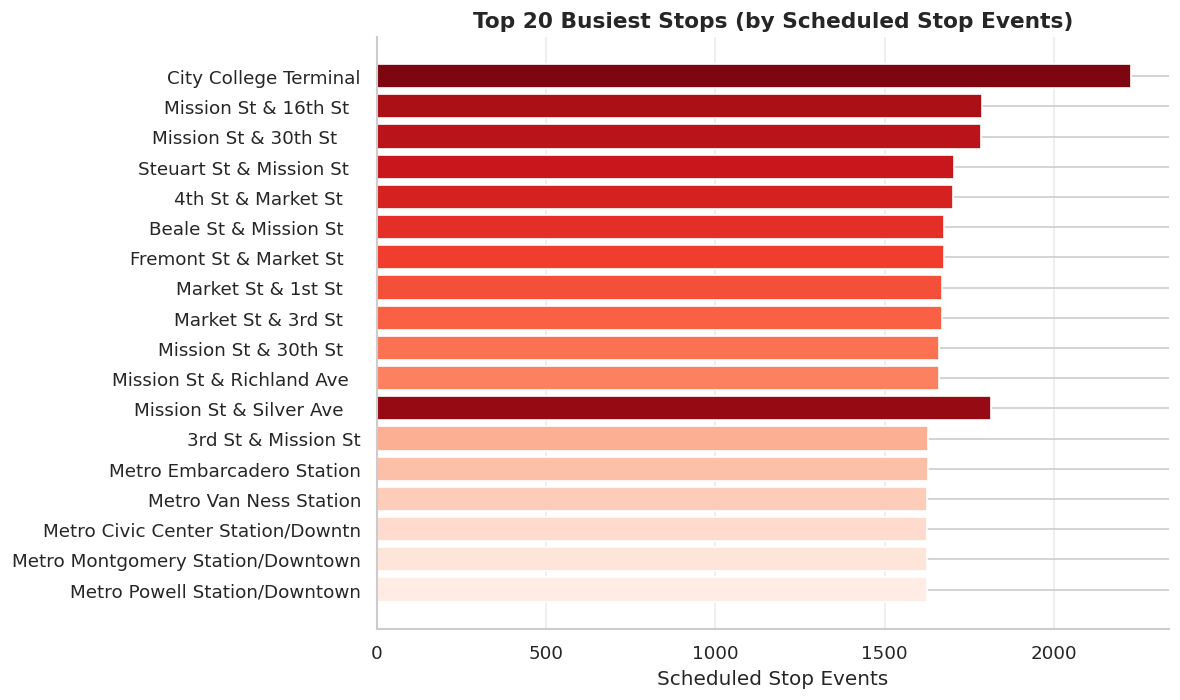

In [103]:
# Visualization: Busiest Stops (by scheduled arrivals)

top_stops = st_df["stop_id"].value_counts().head(20)

# Map stop IDs to names
stop_name_map = stops_df.set_index("stop_id")["stop_name"].to_dict()
top_stops.index = [stop_name_map.get(s, str(s)) for s in top_stops.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = sns.color_palette("Reds_r", len(top_stops))
ax.barh(top_stops.index[::-1], top_stops.values[::-1], color=colors_bar[::-1], edgecolor="white")
ax.set_title("Top 20 Busiest Stops (by Scheduled Stop Events)", fontsize=13, fontweight="bold")
ax.set_xlabel("Scheduled Stop Events")
ax.grid(axis="x", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

## File 6: Calendar

**File:** `calendar.txt`  
**Description:** Defines service patterns using a weekly schedule. Each row is a `service_id` with boolean flags for each day of the week (Monday–Sunday), plus a start and end date for when that service is active. For example, a "weekday" service runs Mon–Fri, while a "weekend" service runs Sat–Sun. This tells the system which trips are running on which days.

In [104]:
# DF Setup
cal_df = dfs["calendar"]

In [105]:
print("Calendar File: Overview")
print(f"Service IDs   : {len(cal_df)}")
print(f"Columns       : {list(cal_df.columns)}")

Calendar File: Overview
Service IDs   : 3
Columns       : ['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'start_date', 'end_date']


In [106]:
# Display Calendar
display(cal_df)

,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
0,M11,1,1,1,1,1,0,0,20250830,20260213
1,2,0,0,0,0,0,1,0,20250830,20260213
2,3,0,0,0,0,0,0,1,20250830,20260213


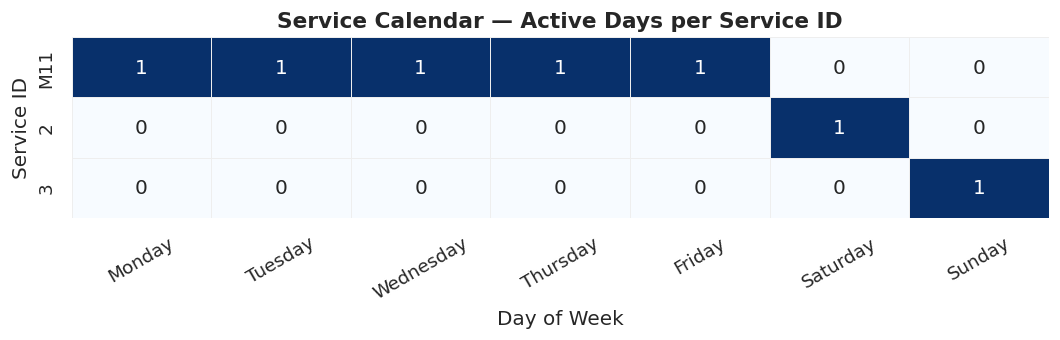

In [107]:
# Visualization: Service Day Heatmap

days = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]
available_days = [d for d in days if d in cal_df.columns]

if available_days:
    heatmap_data = cal_df.set_index("service_id")[available_days]
    
    fig, ax = plt.subplots(figsize=(9, max(3, len(heatmap_data) * 0.5 + 1)))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt="d", cmap="Blues",
        cbar=False, linewidths=0.5, linecolor="#eee",
        ax=ax
    )
    ax.set_title("Service Calendar — Active Days per Service ID", fontsize=13, fontweight="bold")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Service ID")
    ax.set_xticklabels([d.capitalize() for d in available_days], rotation=30)
    plt.tight_layout()
    plt.show()

---

## File 7: Calendar Dates

**File:** `calendar_dates.txt`  
**Description:** Provides exceptions to the regular weekly schedule defined in `calendar.txt`. 

Each row specifies a service ID, a specific date, and an exception type: `1` = service added on this date, `2` = service removed on this date. This file handles holidays, special events, and schedule disruptions.

In [108]:
# DF Setup
cd_df = dfs["calendar_dates"]
cd_df["date"] = pd.to_datetime(cd_df["date"], format="%Y%m%d", errors="coerce")
cd_df["exception_label"] = cd_df["exception_type"].map({1: "Service Added", 2: "Service Removed"})

In [109]:
print("Calendar Dates:— Overview")
print(f"Total Exceptions  : {len(cd_df):,}")
print(f"Date Range        : {cd_df['date'].min().date()} → {cd_df['date'].max().date()}")

Calendar Dates:— Overview
Total Exceptions  : 38
Date Range        : 2025-09-01 → 2026-01-19


In [110]:
print("Exception Type Breakdown:")
print(cd_df["exception_label"].value_counts().to_string())

Exception Type Breakdown:
exception_label
Service Removed    19
Service Added      19


In [111]:
# Display Calnedar (head)
display(cd_df.head(5))

,service_id,date,exception_type,exception_label
0,M11,2025-09-01,2,Service Removed
1,3,2025-09-01,1,Service Added
2,M11,2025-10-13,2,Service Removed
3,2,2025-10-13,1,Service Added
4,M11,2025-11-11,2,Service Removed


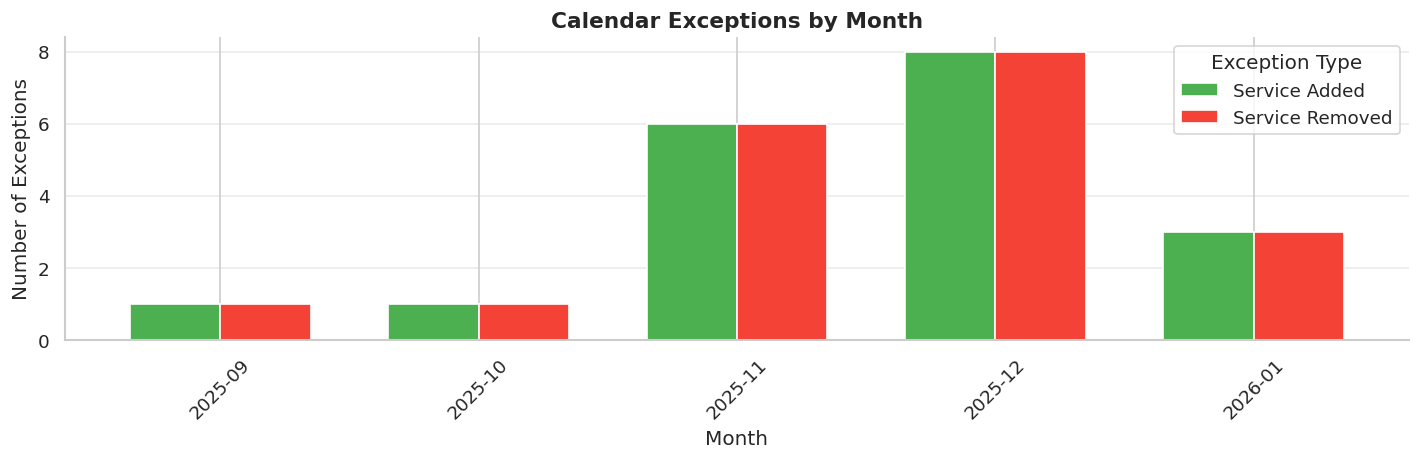

In [112]:
# Visualization: Exceptions Over Time

cd_monthly = cd_df.groupby([cd_df["date"].dt.to_period("M"), "exception_label"]).size().unstack(fill_value=0)
cd_monthly.index = cd_monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
cd_monthly.plot(kind="bar", ax=ax, color=["#4CAF50", "#F44336"], edgecolor="white", width=0.7)
ax.set_title("Calendar Exceptions by Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Exceptions")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Exception Type")
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

---

## File 8: Shapes

**File:** `shapes.txt`  
**Description:** Defines the geographic paths that vehicles travel for each route shape. Each row is a single lat/lon point, with a sequence number, belonging to a `shape_id`. Connecting these points in order draws the route line on a map. Multiple trips can share the same shape.

In [113]:
# DF Setup
shapes_df = dfs["shapes"]

In [114]:
print("Shapes: Overview")
print(f"Total Points   : {len(shapes_df):,}")
print(f"Unique Shapes  : {shapes_df['shape_id'].nunique()}")
print(f"Columns        : {list(shapes_df.columns)}")

Shapes: Overview
Total Points   : 45,050
Unique Shapes  : 291
Columns        : ['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence', 'shape_dist_traveled']


In [115]:
# Display Shapes
display(shapes_df.head(5))

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,23,37.804642,-122.443805,1,0.000000
1,23,37.804646,-122.443881,3,0.004156
2,23,37.804642,-122.443805,4,0.008311
3,23,37.803763,-122.443640,5,0.069670
4,23,37.803710,-122.443615,6,0.073575


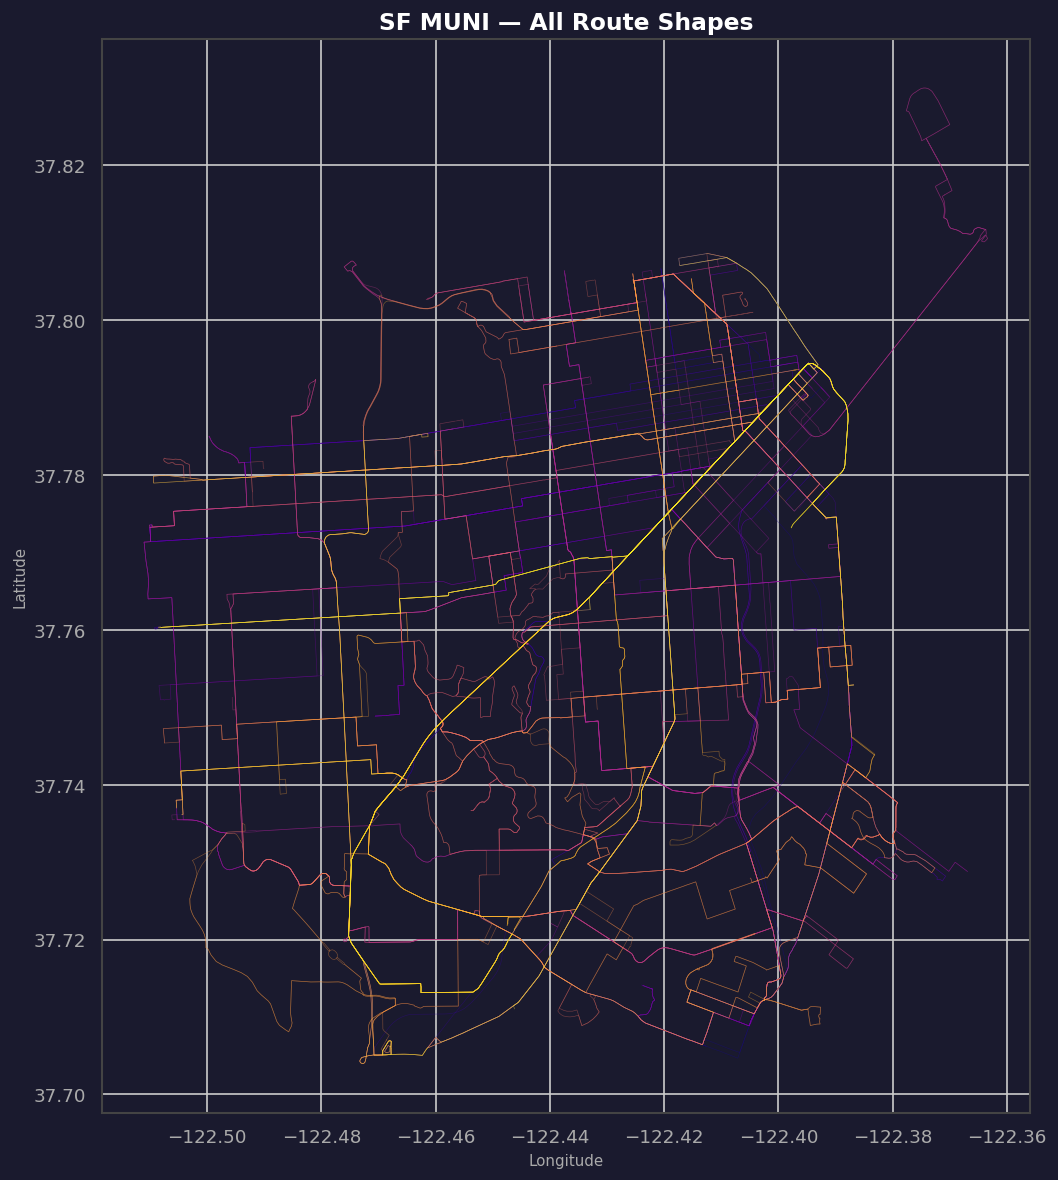

In [116]:
# Visualization: All Route Shapes Overlay Map 

# Draw each shape as a line on the map — reveals the full transit network geometry
fig, ax = plt.subplots(figsize=(9, 10))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

cmap = plt.cm.get_cmap("plasma")
shape_ids = shapes_df["shape_id"].unique()
n = len(shape_ids)

for i, sid in enumerate(shape_ids):
    seg = shapes_df[shapes_df["shape_id"] == sid].sort_values("shape_pt_sequence")
    ax.plot(seg["shape_pt_lon"], seg["shape_pt_lat"],
            linewidth=0.4, alpha=0.4, color=cmap(i / n))

ax.set_title("SF MUNI — All Route Shapes", fontsize=14, fontweight="bold", color="white")
ax.set_xlabel("Longitude", fontsize=9, color="#aaa")
ax.set_ylabel("Latitude", fontsize=9, color="#aaa")
ax.tick_params(colors="#aaa")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")
plt.tight_layout()
plt.show()

---

## Files 9 & 10: Fare Attributes & Fare Rules

**Files:** `fare_attributes.txt` and `fare_rules.txt`  
**Description:**  
- `fare_attributes.txt` defines fare products — price, currency, payment method (on board vs. before boarding), and transfer rules.
- `fare_rules.txt` maps fares to routes (and optionally origin/destination zones), specifying which fare applies to which journey.

Together they describe the ticketing and pricing structure of the MUNI system.

In [117]:
# DF Setup
fare_attr_df = dfs["fare_attributes"]
fare_rules_df = dfs["fare_rules"]

In [118]:
print("Fare Attributes")
print(f"Unique Fare IDs : {len(fare_attr_df)}")
display(fare_attr_df)

Fare Attributes
Unique Fare IDs : 2


,fare_id,price,currency_type,payment_method,transfers,agency_id,transfer_duration
0,1,3,USD,0,NaN,SFMTA,5400
1,2,9,USD,0,0.0,SFMTA,0


In [119]:
print("Fare Rules")
print(f"Total Fare Rules  : {len(fare_rules_df):,}")
print(f"Unique Routes     : {fare_rules_df['route_id'].nunique() if 'route_id' in fare_rules_df.columns else 'N/A'}")

Fare Rules
Total Fare Rules  : 68
Unique Routes     : 68


In [120]:
# Display Fare Rules (head)
display(fare_rules_df.head(10))

,fare_id,route_id
0,1,1
1,1,12
2,1,14
3,1,14R
4,1,15
5,1,18
6,1,19
7,1,1X
8,1,2
9,1,22


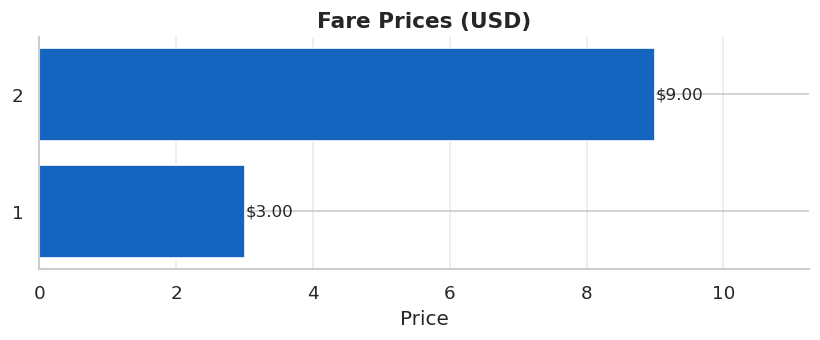

In [121]:
# Visualization: Fare Price Overview

if "price" in fare_attr_df.columns and len(fare_attr_df) > 0:
    fare_attr_df["price"] = pd.to_numeric(fare_attr_df["price"], errors="coerce")

    fig, ax = plt.subplots(figsize=(7, max(3, len(fare_attr_df) * 0.6 + 1)))
    bars = ax.barh(
        fare_attr_df["fare_id"].astype(str),
        fare_attr_df["price"],
        color="#1565C0", edgecolor="white"
    )
    for bar, val in zip(bars, fare_attr_df["price"]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"${val:.2f}", va="center", fontsize=10)
    currency = fare_attr_df["currency_type"].iloc[0] if "currency_type" in fare_attr_df.columns else "USD"
    ax.set_title(f"Fare Prices ({currency})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Price")
    ax.set_xlim(0, fare_attr_df["price"].max() * 1.25)
    ax.grid(axis="x", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()

---

## File 11: Directions
**File:** `directions.txt`  
**Description:** A non-standard GTFS extension (used by some agencies including SFMTA) that provides human-readable direction labels for routes. It maps a `route_id` and `direction_id` (0 or 1) to a descriptive name like "Inbound" or "Outbound", or specific terminus labels like "To Downtown" vs "To the Beach." This supplements the standard `direction_id` field in trips.

In [122]:
# DF Setup
dir_df = dfs["directions"]

In [123]:
print("Directions File: Overview")
print(f"Total Records  : {len(dir_df):,}")
print(f"Columns        : {list(dir_df.columns)}")

Directions File: Overview
Total Records  : 136
Columns        : ['route_id', 'direction_id', 'direction']


In [124]:
# Display Directions (head)
display(dir_df.head(20))

,route_id,direction_id,direction
0,1,0,Outbound
1,1,1,Inbound
2,2,0,Outbound
3,2,1,Inbound
4,5,0,Outbound
5,5,1,Inbound
6,6,0,Outbound
7,6,1,Inbound
8,7,0,Outbound
9,7,1,Inbound


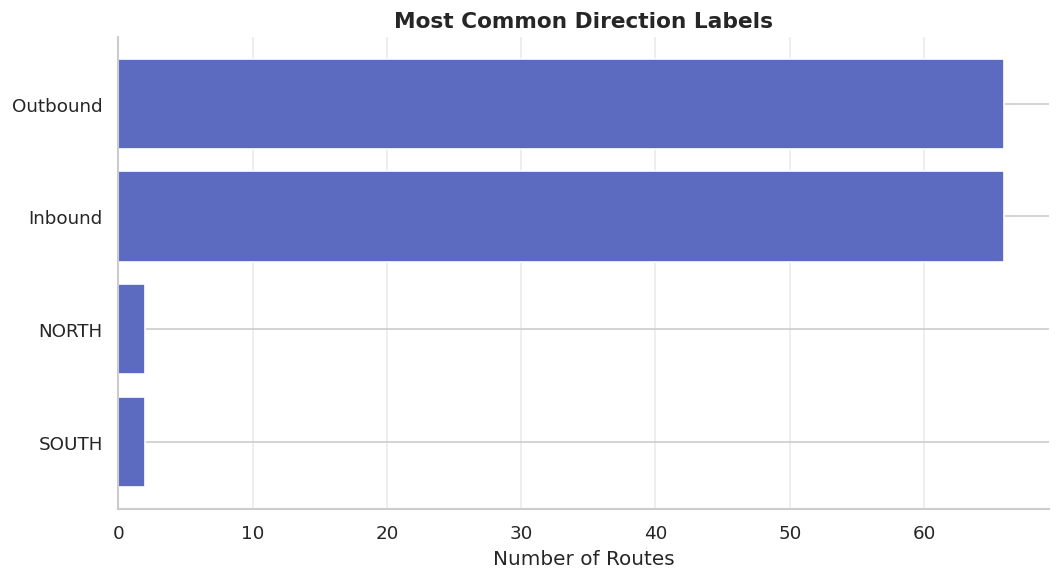

In [125]:
# Visualiztion: Most Common Direction Labels

dir_col = [c for c in dir_df.columns if "direction" in c.lower() and "id" not in c.lower()]
if dir_col:
    label_counts = dir_df[dir_col[0]].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(label_counts.index[::-1], label_counts.values[::-1],
            color="#5C6BC0", edgecolor="white")
    ax.set_title("Most Common Direction Labels", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Routes")
    ax.grid(axis="x", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()

---

## File 12: Timepoints

**File:** `timepoints.txt`  
**Description:** Another non-standard GTFS extension specifying which stops in a trip are "timepoints" designated stops where vehicles are expected to maintain schedule adherence. Stops between timepoints are approximate. This is operationally important: drivers must not be early at timepoints but may be flexible at non-timepoints. Used for performance tracking.

In [126]:
# DF Setup
tp_df = dfs["timepoints"]

In [127]:
print("Timepoints File: Overview")
print(f"Total Records  : {len(tp_df):,}")
print(f"Columns        : {list(tp_df.columns)}")

Timepoints File: Overview
Total Records  : 244,847
Columns        : ['trip_id', 'stop_id']


In [128]:
# Display Timepoints
display(tp_df.head(10))

,trip_id,stop_id
0,11929569_M11,5224
1,11929569_M11,7219
2,11929569_M21,5240
3,11929569_M21,4510
4,11929569_M21,7217
5,11929569_M21,6996
6,11929569_M21,3912
7,11929569_M21,5199
8,11929569_M21,5224
9,11929569_M21,7219


## Network Graph: Stop Connectivity

**Description:** This section constructs a **social/transit network graph** where:
- **Nodes** = transit stops
- **Edges** = sequential stop pairs that appear together on a trip

This reveals which stops are highly connected hubs versus peripheral endpoints, and which corridors carry the most service. Node size reflects how many routes serve a stop (degree centrality).

In [129]:
# Build Stop-to-Stop Network

# Use a manageable subset: pick trips from the top N routes
TOP_N_ROUTES = 15

top_route_ids = trips_df.groupby("route_id").size().sort_values(ascending=False).head(TOP_N_ROUTES).index.tolist()
top_trip_ids = trips_df[trips_df["route_id"].isin(top_route_ids)]["trip_id"].unique()

# Filter stop_times to those trips
sub_st = st_df[st_df["trip_id"].isin(top_trip_ids)].sort_values(["trip_id", "stop_sequence"])

# Build edges: consecutive stop pairs within each trip
edges = []
for trip_id, group in sub_st.groupby("trip_id"):
    stop_list = group["stop_id"].tolist()
    for i in range(len(stop_list) - 1):
        edges.append((stop_list[i], stop_list[i + 1]))

# Edge weights = number of times a connection appears
edge_counts = Counter(edges)

# Build graph
G = nx.Graph()
for (u, v), weight in edge_counts.items():
    if G.has_edge(u, v):
        G[u][v]["weight"] += weight
    else:
        G.add_edge(u, v, weight=weight)

print(f"Graph built from top {TOP_N_ROUTES} routes")
print(f"  Nodes (stops)  : {G.number_of_nodes():,}")
print(f"  Edges (links)  : {G.number_of_edges():,}")

Graph built from top 15 routes
  Nodes (stops)  : 1,020
  Edges (links)  : 1,084


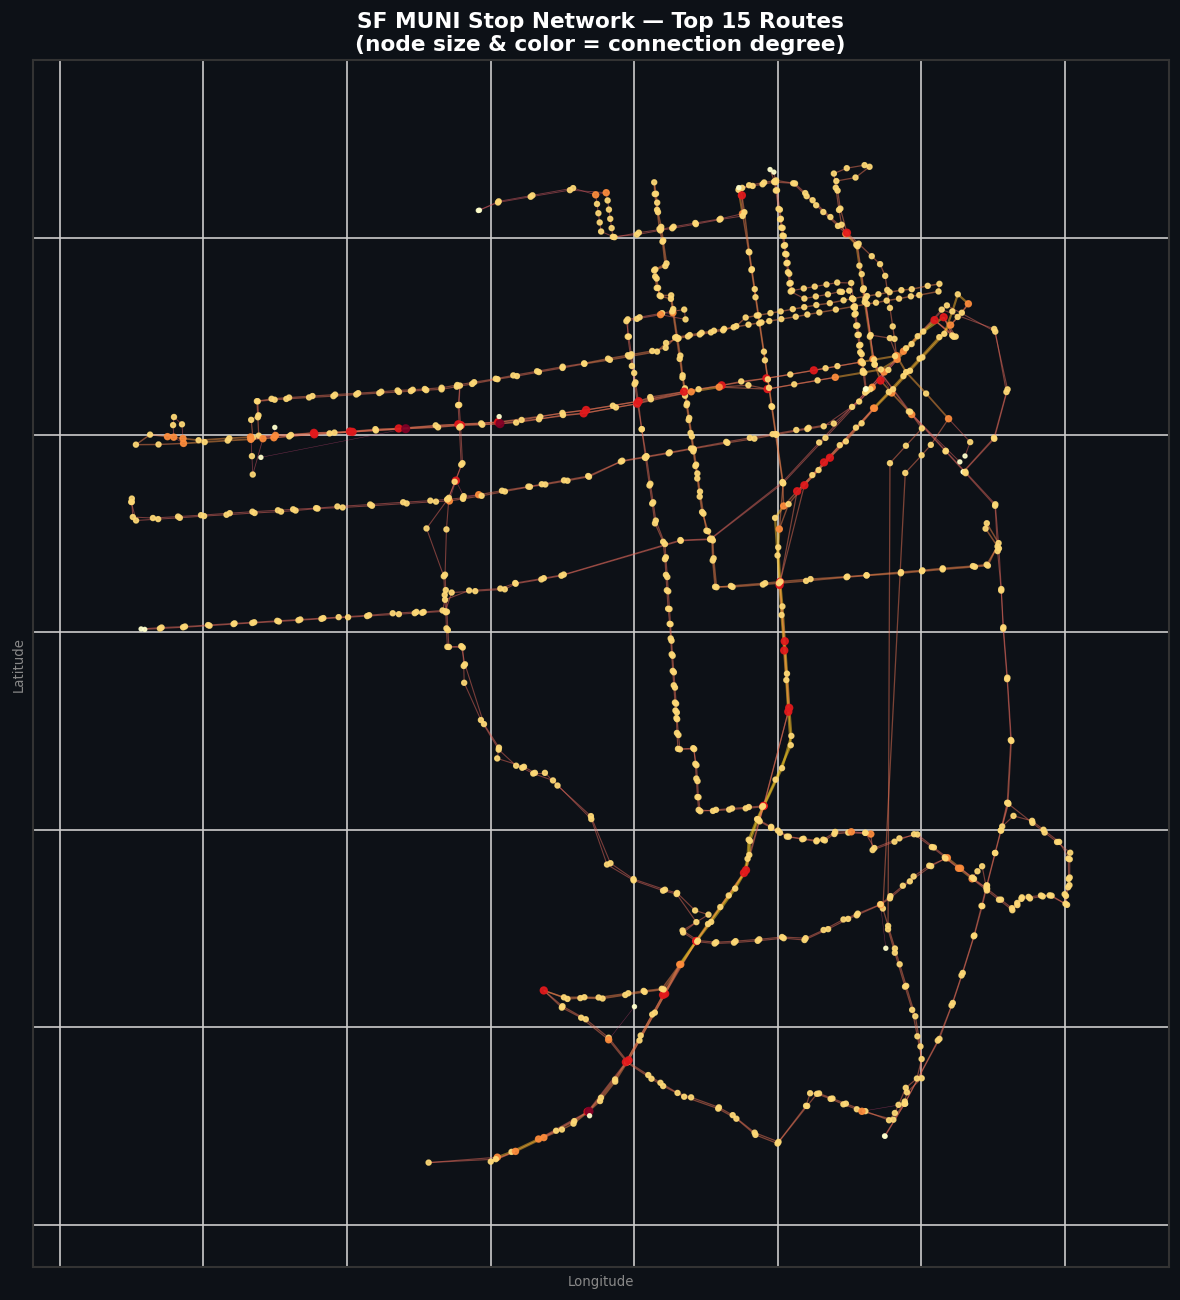

In [130]:
# Visualization: Network Graph (geographic layout)

# Position nodes using actual lat/lon coordinates
pos = {}
for node in G.nodes():
    row = stops_df[stops_df["stop_id"] == node]
    if not row.empty:
        pos[node] = (float(row.iloc[0]["stop_lon"]), float(row.iloc[0]["stop_lat"]))

# Only keep nodes with known positions
nodes_with_pos = [n for n in G.nodes() if n in pos]
H = G.subgraph(nodes_with_pos)

# Compute degree centrality for node sizing
degree = dict(H.degree())
node_sizes = [max(5, degree[n] * 4) for n in H.nodes()]
edge_weights = [H[u][v]["weight"] for u, v in H.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_alpha = [0.1 + 0.5 * (w / max_w) for w in edge_weights]

fig, ax = plt.subplots(figsize=(10, 11))
ax.set_facecolor("#0d1117")
fig.patch.set_facecolor("#0d1117")

# Draw edges
nx.draw_networkx_edges(
    H, pos, ax=ax,
    edge_color=[plt.cm.plasma(0.5 + 0.4 * (w / max_w)) for w in edge_weights],
    width=[0.3 + 1.2 * (w / max_w) for w in edge_weights],
    alpha=0.5
)
# Draw nodes
nx.draw_networkx_nodes(
    H, pos, ax=ax,
    node_size=node_sizes,
    node_color=[degree[n] for n in H.nodes()],
    cmap="YlOrRd",
    alpha=0.9
)

ax.set_title(
    f"SF MUNI Stop Network — Top {TOP_N_ROUTES} Routes\n(node size & color = connection degree)",
    fontsize=13, fontweight="bold", color="white"
)
ax.tick_params(colors="#888")
ax.set_xlabel("Longitude", color="#888", fontsize=8)
ax.set_ylabel("Latitude", color="#888", fontsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor("#333")
plt.tight_layout()
plt.show()

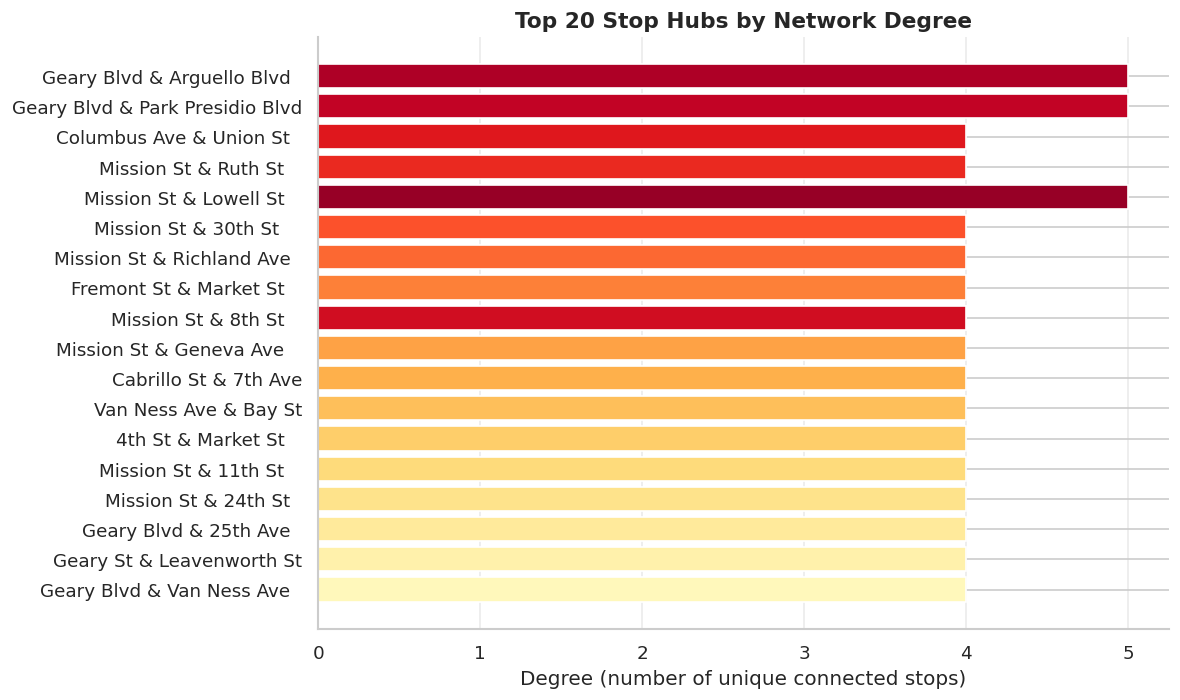

In [131]:
# Visualization: Top Hub Stops by Network Degree

degree_series = pd.Series(dict(G.degree())).sort_values(ascending=False).head(20)
degree_series.index = [stop_name_map.get(s, str(s)) for s in degree_series.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors_d = sns.color_palette("YlOrRd", len(degree_series))
ax.barh(degree_series.index[::-1], degree_series.values[::-1],
        color=colors_d, edgecolor="white")
ax.set_title("Top 20 Stop Hubs by Network Degree", fontsize=13, fontweight="bold")
ax.set_xlabel("Degree (number of unique connected stops)")
ax.grid(axis="x", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

---

## File 14: Route-to-Route Sharing Network

**Description:** A second network graph at the **route level**. Two routes are connected if they **share at least one stop**. This reveals route clusters, transfer opportunities, and which routes act as connectors across the system. Edge weight = number of shared stops.

In [132]:
# Build Route Sharing Graph

# Map each trip to its route
trip_to_route = trips_df.set_index("trip_id")["route_id"].to_dict()

# Map each stop to the set of routes that visit it
sub_st_all = st_df.copy()
sub_st_all["route_id"] = sub_st_all["trip_id"].map(trip_to_route)
sub_st_all = sub_st_all.dropna(subset=["route_id"])

stop_routes = sub_st_all.groupby("stop_id")["route_id"].apply(set).to_dict()

# Build edges between routes sharing stops
from itertools import combinations
route_edges = Counter()
for stop, route_set in stop_routes.items():
    route_list = list(route_set)
    for a, b in combinations(sorted(route_list), 2):
        route_edges[(a, b)] += 1

# Build the route graph
RG = nx.Graph()
for (a, b), shared in route_edges.items():
    RG.add_edge(a, b, weight=shared)

# Relabel with short names if possible
if "route_short_name" in routes_df.columns:
    short_map = routes_df.set_index("route_id")["route_short_name"].to_dict()
    RG = nx.relabel_nodes(RG, lambda x: short_map.get(x, str(x)))

print(f"Route Sharing Graph")
print(f"  Nodes (routes) : {RG.number_of_nodes()}")
print(f"  Edges (pairs)  : {RG.number_of_edges():,}")

Route Sharing Graph
  Nodes (routes) : 66
  Edges (pairs)  : 393


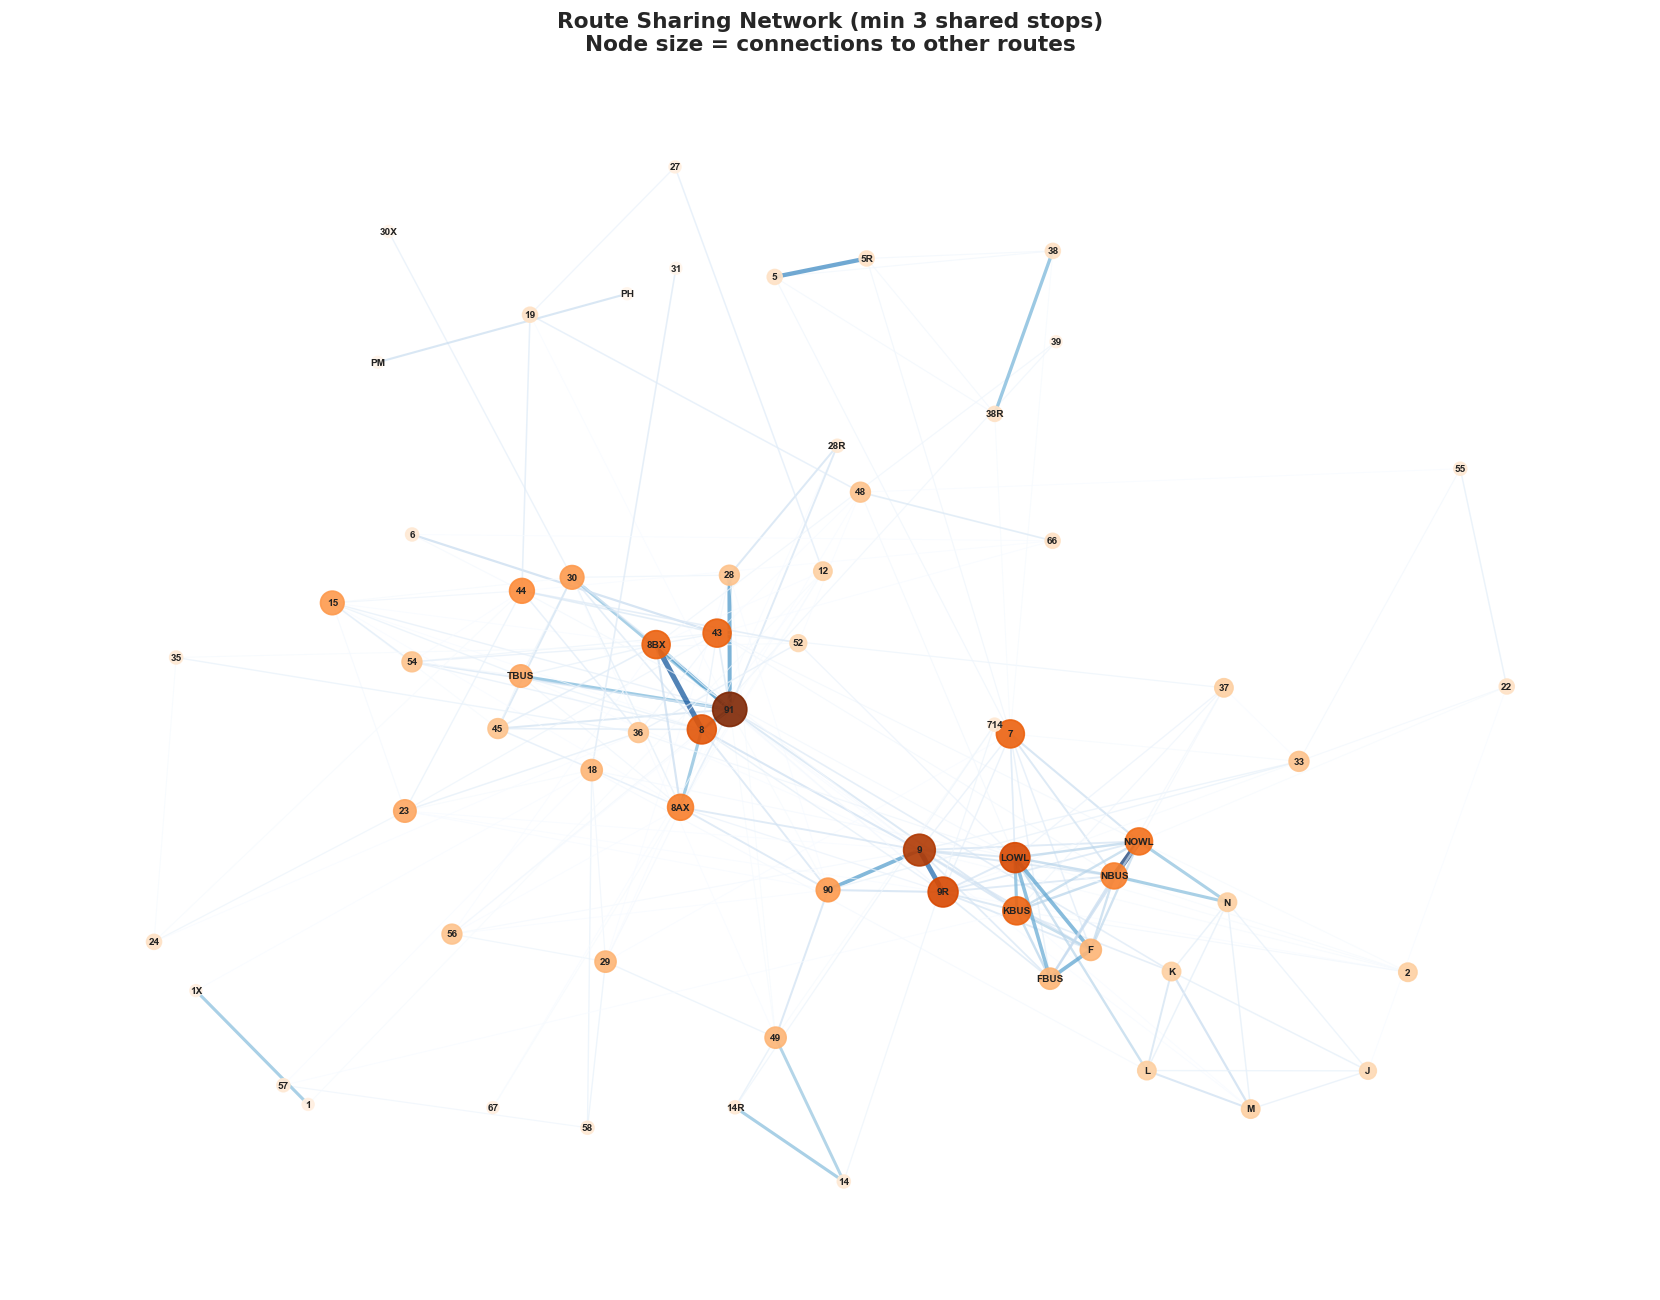

In [133]:
# Visualization: Route-to-Route Sharing Network

# Use spring layout and show only edges with meaningful sharing
MIN_SHARED = 3  # filter weak connections
RG_filtered = nx.Graph([(u, v, d) for u, v, d in RG.edges(data=True) if d["weight"] >= MIN_SHARED])

r_degree = dict(RG_filtered.degree())
r_sizes = [max(50, r_degree.get(n, 1) * 20) for n in RG_filtered.nodes()]
r_edge_w = [RG_filtered[u][v]["weight"] for u, v in RG_filtered.edges()]
max_rw = max(r_edge_w) if r_edge_w else 1

pos_r = nx.spring_layout(RG_filtered, seed=42, k=1.5)

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_facecolor("#f8f9fa")

nx.draw_networkx_edges(
    RG_filtered, pos_r, ax=ax,
    width=[0.5 + 3 * (w / max_rw) for w in r_edge_w],
    edge_color=r_edge_w, edge_cmap=plt.cm.Blues,
    alpha=0.7
)
nx.draw_networkx_nodes(
    RG_filtered, pos_r, ax=ax,
    node_size=r_sizes,
    node_color=[r_degree.get(n, 0) for n in RG_filtered.nodes()],
    cmap="Oranges", alpha=0.9
)
nx.draw_networkx_labels(
    RG_filtered, pos_r, ax=ax,
    font_size=6, font_weight="bold", font_color="#222"
)

ax.set_title(
    f"Route Sharing Network (min {MIN_SHARED} shared stops)\nNode size = connections to other routes",
    fontsize=13, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Summary Statistics
A consolidated overview of the entire GTFS dataset.

In [134]:
print("  SF MUNI GTFS — System Summary")
print("")
print(f"  Transit Agency     : {dfs['agency']['agency_name'].iloc[0] if 'agency_name' in dfs['agency'].columns else 'SFMTA'}")
print(f"  Total Routes       : {len(routes_df):,}")
print(f"  Total Trips        : {len(trips_df):,}")
print(f"  Total Stops        : {len(stops_df):,}")
print(f"  Total Stop Events  : {len(st_df):,}")
print(f"  Shape Points       : {len(shapes_df):,}")
print(f"  Unique Shapes      : {shapes_df['shape_id'].nunique():,}")
print(f"  Service IDs        : {len(cal_df)}")
print(f"  Calendar Exceptions: {len(cd_df):,}")
print(f"  Fare Products      : {len(fare_attr_df)}")
print(f"  Fare Rules         : {len(fare_rules_df):,}")

# Route type breakdown
print("\nRoute Breakdown by Type:")
type_labels = {0: "Tram/Streetcar", 1: "Subway/Metro", 3: "Bus", 5: "Cable Car"}
for rtype, count in routes_df["route_type"].value_counts().items():
    label = type_labels.get(rtype, f"Type {rtype}")
    print(f"  {label:<20}: {count}")

# Average stops per trip
avg_stops = st_df.groupby("trip_id")["stop_id"].count().mean()
print(f"\nAvg Stops per Trip   : {avg_stops:.1f}")

# Trips per route
avg_trips = trips_df.groupby("route_id").size().mean()
print(f"Avg Trips per Route  : {avg_trips:.1f}")

  SF MUNI GTFS — System Summary

  Transit Agency     : San Francisco Municipal Transportation Agency
  Total Routes       : 68
  Total Trips        : 34,632
  Total Stops        : 3,243
  Total Stop Events  : 1,296,224
  Shape Points       : 45,050
  Unique Shapes      : 291
  Service IDs        : 3
  Calendar Exceptions: 38
  Fare Products      : 2
  Fare Rules         : 68

Route Breakdown by Type:
  Bus                 : 57
  Tram/Streetcar      : 8
  Cable Car           : 3

Avg Stops per Trip   : 37.4
Avg Trips per Route  : 509.3


## References
List out the resources and references used for cultivating this exploration file.

- **GTFS Specification:** https://gtfs.org/schedule/reference/
- **SFMTA Developer Resources:** https://www.sfmta.com/reports/gtfs-transit-data
- **GTFS Best Practices:** https://gtfs.org/schedule/best-practices/
- **Validation Tool:** https://gtfs-validator.mobilitydata.org/